In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load Fashion-MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
print("Training data:", x_train.shape)
print("Test data:", x_test.shape)

Training data: (60000, 28, 28)
Test data: (10000, 28, 28)


In [ ]:
# Flatten images for Dense network
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

In [ ]:
x_train_flat.shape

(60000, 784)

In [ ]:
latent_dim = 2

In [ ]:
# ---------------- Encoder ----------------
inputs_dense = layers.Input(shape=(784,))
h = layers.Dense(512, activation="relu")(inputs_dense)
h = layers.Dense(256, activation="relu")(h)

z_mean = layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)

In [ ]:
# Sampling function
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

encoder = models.Model(inputs_dense, [z_mean, z_log_var, z], name="encoder")

In [ ]:

# ---------------- Decoder ----------------
latent_inputs = layers.Input(shape=(latent_dim,))
h = layers.Dense(256, activation="relu")(latent_inputs)
h = layers.Dense(512, activation="relu")(h)
outputs = layers.Dense(784, activation="sigmoid")(h)

decoder = models.Model(latent_inputs, outputs, name="decoder")

In [ ]:
z_mean, z_log_var, z = encoder(inputs_dense)
reconstruction = decoder(z)

vae = models.Model(inputs_dense, reconstruction, name="vae")

In [ ]:
class VAELossLayer(layers.Layer):
    def call(self, inputs):
        x, x_recon, z_mean, z_log_var = inputs
        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(x, x_recon)
        ) * 784
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        self.add_loss(reconstruction_loss + kl_loss)
        return x_recon

outputs = VAELossLayer()([inputs_dense, reconstruction, z_mean, z_log_var])
vae = models.Model(inputs_dense, outputs, name="vae")

In [ ]:
vae.compile(optimizer="adam")

In [ ]:
vae.fit(x_train_flat, x_train_flat,
        epochs=10,
        batch_size=128,
        validation_data=(x_test_flat, x_test_flat))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 327.5367 - val_loss: 274.8169
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 272.0327 - val_loss: 269.5743
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 267.1762 - val_loss: 267.0428
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 264.8159 - val_loss: 265.6991
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 264.2079 - val_loss: 264.9742
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 262.9228 - val_loss: 263.6908
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 261.9828 - val_loss: 262.8430
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 262.0734 - val_loss: 262.1133
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 260.7296 - val_loss: 261.9893
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 260.2944 - val_loss: 261.5558


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━

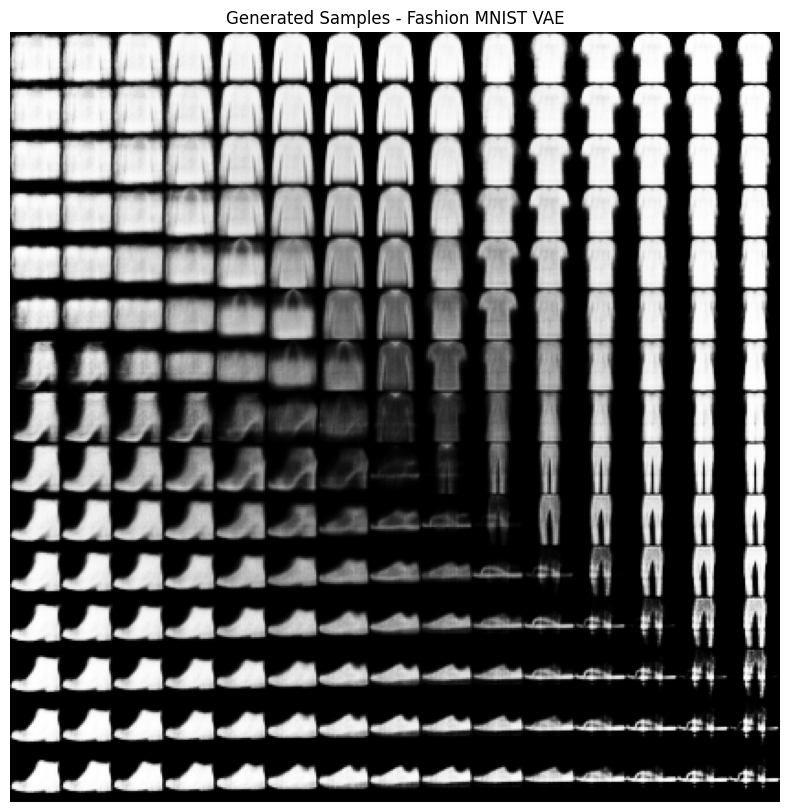

In [ ]:
n = 15
digit_size = 28
figure = np.zeros((digit_size*n, digit_size*n))
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i*digit_size:(i+1)*digit_size,
               j*digit_size:(j+1)*digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.title("Generated Samples - Fashion MNIST VAE")
plt.show()